## Import Libraries

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report

Load Dataset

In [6]:
#Load Dataset
df=pd.read_csv("train.csv")

## Phase 1: Exploratory Data Analysis (EDA)

In [7]:
df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [8]:
df=df.drop(columns=["id"])

In [9]:
df.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [10]:
df.shape

(630000, 20)

In [11]:
df.dtypes

Soil_Type                   object
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             float64
Electrical_Conductivity    float64
Temperature_C              float64
Humidity                   float64
Rainfall_mm                float64
Sunlight_Hours             float64
Wind_Speed_kmh             float64
Crop_Type                   object
Crop_Growth_Stage           object
Season                      object
Irrigation_Type             object
Water_Source                object
Field_Area_hectare         float64
Mulching_Used               object
Previous_Irrigation_mm     float64
Region                      object
Irrigation_Need             object
dtype: object

In [12]:
df.isnull().sum()

Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Soil_Type                630000 non-null  object 
 1   Soil_pH                  630000 non-null  float64
 2   Soil_Moisture            630000 non-null  float64
 3   Organic_Carbon           630000 non-null  float64
 4   Electrical_Conductivity  630000 non-null  float64
 5   Temperature_C            630000 non-null  float64
 6   Humidity                 630000 non-null  float64
 7   Rainfall_mm              630000 non-null  float64
 8   Sunlight_Hours           630000 non-null  float64
 9   Wind_Speed_kmh           630000 non-null  float64
 10  Crop_Type                630000 non-null  object 
 11  Crop_Growth_Stage        630000 non-null  object 
 12  Season                   630000 non-null  object 
 13  Irrigation_Type          630000 non-null  object 
 14  Wate

In [14]:
df.nunique()

Soil_Type                      4
Soil_pH                      341
Soil_Moisture               5223
Organic_Carbon               131
Electrical_Conductivity      341
Temperature_C               2934
Humidity                    6475
Rainfall_mm                19308
Sunlight_Hours               701
Wind_Speed_kmh              1935
Crop_Type                      6
Crop_Growth_Stage              4
Season                         3
Irrigation_Type                4
Water_Source                   4
Field_Area_hectare          1466
Mulching_Used                  2
Previous_Irrigation_mm     10110
Region                         5
Irrigation_Need                3
dtype: int64

In [15]:
class_counts = df["Irrigation_Need"].value_counts()
class_percentages = df["Irrigation_Need"].value_counts(normalize=True) * 100
balance_df = pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_percentages})
print(balance_df.round(2))

                  Count  Percentage (%)
Irrigation_Need                        
Low              369917           58.72
Medium           239074           37.95
High              21009            3.33


C:\Users\mirol\AppData\Local\Temp\ipykernel_7400\2174210472.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Irrigation_Need", palette='viridis')


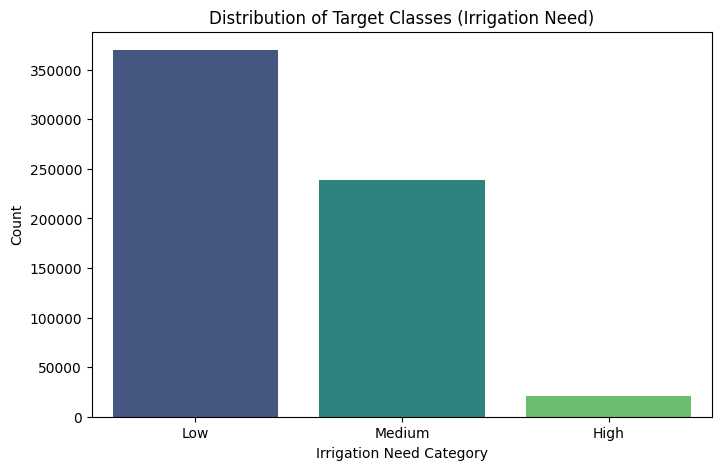

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Irrigation_Need", palette='viridis')
plt.title('Distribution of Target Classes (Irrigation Need)')
plt.xlabel('Irrigation Need Category')
plt.ylabel('Count')
plt.show()

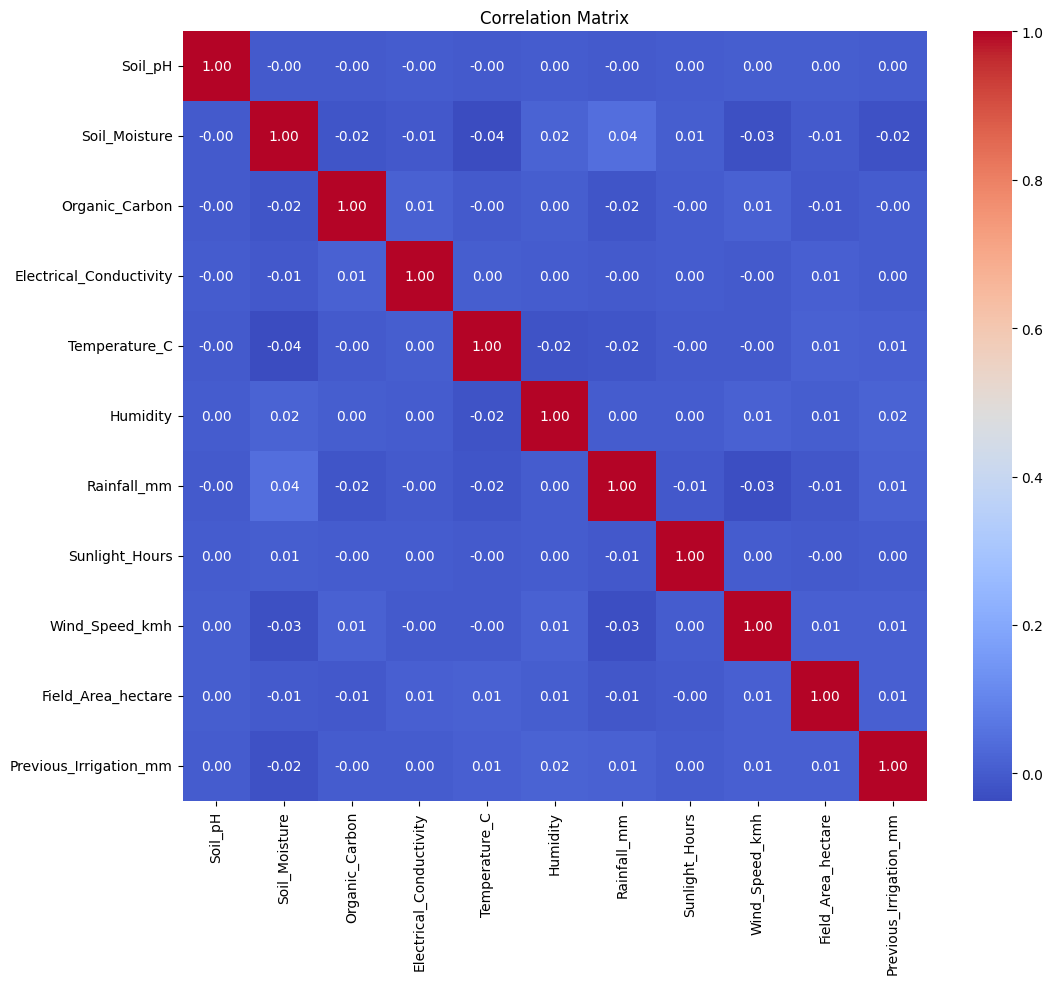

In [17]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [18]:
highly_correlated = False
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.8:
            colname_i = corr_matrix.columns[i]
            colname_j = corr_matrix.columns[j]
            print(f"- {colname_i} & {colname_j} (r = {corr_value:.2f})")
            highly_correlated = True

if not highly_correlated:
    print("- No feature pairs found with an absolute correlation greater than 0.8.")

- No feature pairs found with an absolute correlation greater than 0.8.


## Phase 2: Data Preprocessing & Engineering

In [19]:
y = df["Irrigation_Need"]
X = df.drop(columns=["Irrigation_Need"])

In [20]:
threshold = 0.8


In [21]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)


X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.25, 
    random_state=42, 
    stratify=y_temp
)

In [22]:

num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

In [26]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val) 
X_test_processed = preprocessor.transform(X_test)

# Convert back to DataFrame for easier viewing/debugging
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_features)

X_train_final = pd.DataFrame(X_train_processed, columns=all_feature_names)

print("\n--- Processed Training Data Preview ---")
display(X_train_final.head())


--- Processed Training Data Preview ---


,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Mulching_Used_Yes,Region_East,Region_North,Region_South,Region_West
0,-0.890898,-0.751153,1.222431,0.699370,-0.634464,1.276695,1.161987,-1.296630,0.282948,1.407163,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,-1.497749,1.545069,0.539003,-0.812526,0.190240,-0.053624,-1.235693,1.653037,-0.305716,-0.970710,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.663328,0.421386,0.374980,-1.578974,-0.627505,-1.038050,-0.025875,0.973114,0.198602,-0.800015,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.934244,1.529191,-1.183237,-1.515978,-1.027677,0.605703,-1.373090,0.368182,-1.258123,-0.999159,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,-1.465239,-1.525517,1.249768,1.381823,-0.524272,-1.417417,-0.416957,0.628153,-0.275844,0.935382,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Phase 3: Model Development 

In [27]:
# XGBoost requires numeric target labels. 
label_encoder = LabelEncoder()

# Fit on training labels, transform train, val, and test labels
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded   = label_encoder.transform(y_val)
y_test_encoded  = label_encoder.transform(y_test) 

print(f"Target classes mapped to: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
print("\n--- Training Models ---")

Target classes mapped to: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

--- Training Models ---


In [38]:
print("Training Logistic Regression...")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_processed, y_train_encoded)

# Predict and evaluate on Validation Set
log_reg_val_preds = log_reg.predict(X_val_processed)
log_reg_acc = balanced_accuracy_score(y_val_encoded, log_reg_val_preds)

Training Logistic Regression...


In [29]:
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_processed, y_train_encoded)

# Predict and evaluate on Validation Set
rf_val_preds = rf_model.predict(X_val_processed)
rf_acc = balanced_accuracy_score(y_val_encoded, rf_val_preds)

Training Random Forest...


In [30]:
print("Training XGBoost...")
# eval_metric='mlogloss' suppresses a common XGBoost warning for multiclass classification
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train_processed, y_train_encoded)

# Predict and evaluate on Validation Set
xgb_val_preds = xgb_model.predict(X_val_processed)
xgb_acc = balanced_accuracy_score(y_val_encoded, xgb_val_preds)

Training XGBoost...


c:\Users\mirol\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:19:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [31]:
print("\n--- Model Comparison on Validation Set ---")
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Validation Balanced Accuracy': [log_reg_acc, rf_acc, xgb_acc]
}).sort_values(by='Validation Balanced Accuracy', ascending=False)

# Display the final leaderboard
display(results_df)


--- Model Comparison on Validation Set ---


,Model,Validation Balanced Accuracy
2,XGBoost,0.961795
1,Random Forest,0.952932
0,Logistic Regression,0.775705


In [35]:
log_reg1 = LogisticRegression(C=10.0, max_iter=1000, random_state=42) 
print("Training Logistic Regression...")
log_reg.fit(X_train_processed, y_train_encoded)

# Predict and evaluate on Validation Set
log_reg_val_preds = log_reg.predict(X_val_processed)
log_reg_acc = balanced_accuracy_score(y_val_encoded, log_reg_val_preds)
print("\n--- Updated Logistic Regression Performance ---")
print(f"Logistic Regression Validation Balanced Accuracy: {log_reg_acc:.4f}")

Training Logistic Regression...

--- Updated Logistic Regression Performance ---
Logistic Regression Validation Balanced Accuracy: 0.7758


In [36]:
log_reg2 = LogisticRegression(C=100.0, max_iter=1000, random_state=42) 
print("Training Logistic Regression...")
log_reg.fit(X_train_processed, y_train_encoded)

# Predict and evaluate on Validation Set
log_reg_val_preds = log_reg.predict(X_val_processed)
log_reg_acc = balanced_accuracy_score(y_val_encoded, log_reg_val_preds)
print("\n--- Updated Logistic Regression Performance ---")
print(f"Logistic Regression Validation Balanced Accuracy: {log_reg_acc:.4f}")

Training Logistic Regression...

--- Updated Logistic Regression Performance ---
Logistic Regression Validation Balanced Accuracy: 0.7758


## Phase 4: Evaluation & Performance Strategy

In [39]:
from sklearn.metrics import balanced_accuracy_score

print("--- Evaluating All Models on Final Unseen Test Set ---")

# ==========================================
# 1. Predict and Evaluate: Logistic Regression
# ==========================================
log_reg_test_preds = log_reg.predict(X_test_processed)
log_reg_test_acc = balanced_accuracy_score(y_test_encoded, log_reg_test_preds)

# ==========================================
# 2. Predict and Evaluate: Random Forest
# ==========================================
rf_test_preds = rf_model.predict(X_test_processed)
rf_test_acc = balanced_accuracy_score(y_test_encoded, rf_test_preds)

# ==========================================
# 3. Predict and Evaluate: XGBoost
# ==========================================
xgb_test_preds = xgb_model.predict(X_test_processed)
xgb_test_acc = balanced_accuracy_score(y_test_encoded, xgb_test_preds)

# 4. Final Test Performance Leaderboard
# ==========================================
test_results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Test Balanced Accuracy': [log_reg_test_acc, rf_test_acc, xgb_test_acc]
}).sort_values(by='Test Balanced Accuracy', ascending=False)

# Display the final results
print("\nFinal Test Set Leaderboard:")
display(test_results_df)

# 5. Extracting the Ultimate Winner
# Programmatically grab the name and score of the top model
top_model_name = test_results_df.iloc[0]['Model']
top_model_score = test_results_df.iloc[0]['Test Balanced Accuracy']

print(f"\nTop Performing Architecture: {top_model_name} ({top_model_score:.4f} Balanced Accuracy)")

--- Evaluating All Models on Final Unseen Test Set ---

Final Test Set Leaderboard:


,Model,Test Balanced Accuracy
2,XGBoost,0.964481
1,Random Forest,0.957031
0,Logistic Regression,0.778738



Top Performing Architecture: XGBoost (0.9645 Balanced Accuracy)


C:\Users\mirol\AppData\Local\Temp\ipykernel_7400\2214088061.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


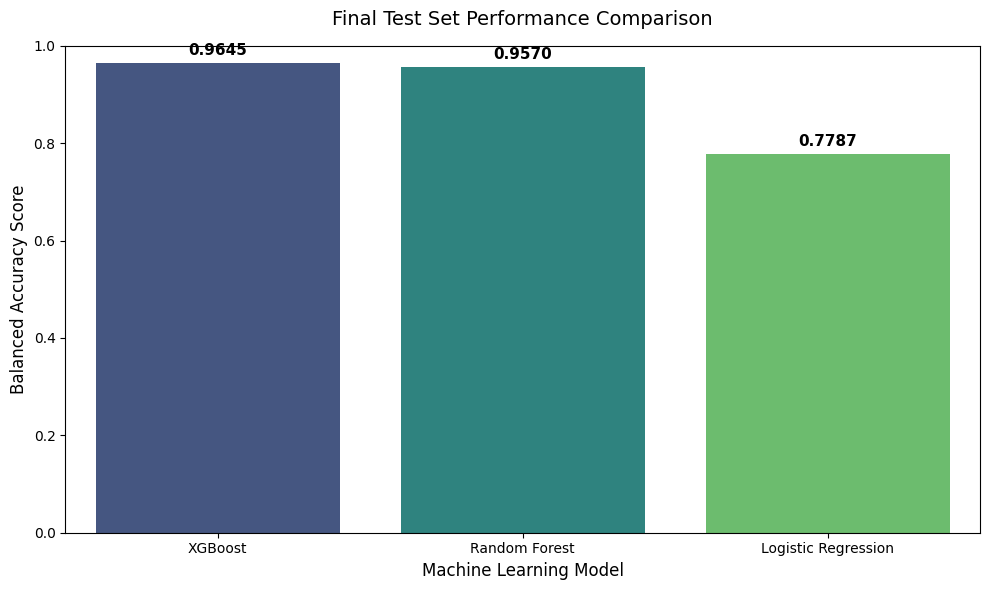

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Create the bar plot using the dataframe we just built
ax = sns.barplot(
    data=test_results_df, 
    x='Model', 
    y='Test Balanced Accuracy', 
    palette='viridis'
)

# Add titles and adjust labels for presentation quality
plt.title('Final Test Set Performance Comparison', fontsize=14, pad=15)
plt.xlabel('Machine Learning Model', fontsize=12)
plt.ylabel('Balanced Accuracy Score', fontsize=12)

# Set the y-axis limit from 0 to 1 to properly represent an accuracy percentage
plt.ylim(0, 1.0) 

# Add the exact scores on top of each bar for quick reading
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [45]:
if top_model_name == 'Logistic Regression':
    best_model = log_reg
    best_test_preds = log_reg_test_preds
elif top_model_name == 'Random Forest':
    best_model = rf_model
    best_test_preds = rf_test_preds
else:
    best_model = xgb_model
    best_test_preds = xgb_test_preds

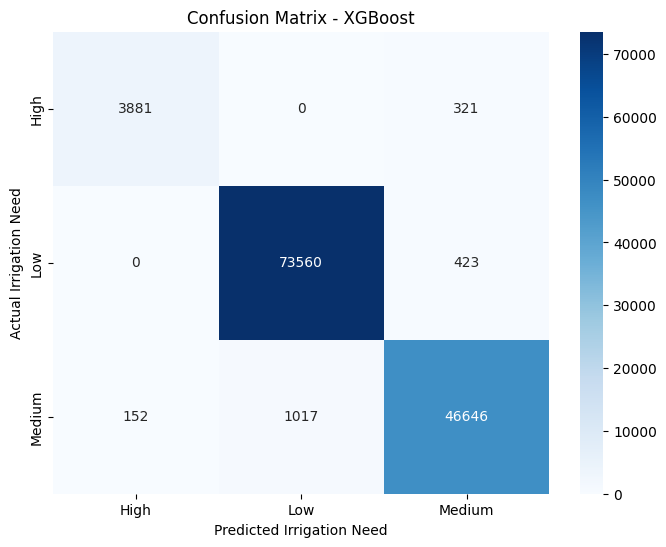

--- Detailed Classification Report ---
              precision    recall  f1-score   support

        High       0.96      0.92      0.94      4202
         Low       0.99      0.99      0.99     73983
      Medium       0.98      0.98      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000



In [47]:
# Generate the confusion matrix for the winning model
cm = confusion_matrix(y_test_encoded, best_test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {top_model_name}')
plt.ylabel('Actual Irrigation Need')
plt.xlabel('Predicted Irrigation Need')
plt.show()

print("--- Detailed Classification Report ---")
print(classification_report(y_test_encoded, best_test_preds, target_names=label_encoder.classes_))

In [48]:
if hasattr(best_model, 'feature_importances_'):
    # Tree-based models (Random Forest, XGBoost)
    importances = best_model.feature_importances_
else:
    # Linear models (Logistic Regression) use coefficients
    # Taking the mean of absolute coefficients across all classes
    importances = np.mean(np.abs(best_model.coef_), axis=0)

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

C:\Users\mirol\AppData\Local\Temp\ipykernel_7400\999890762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='viridis')


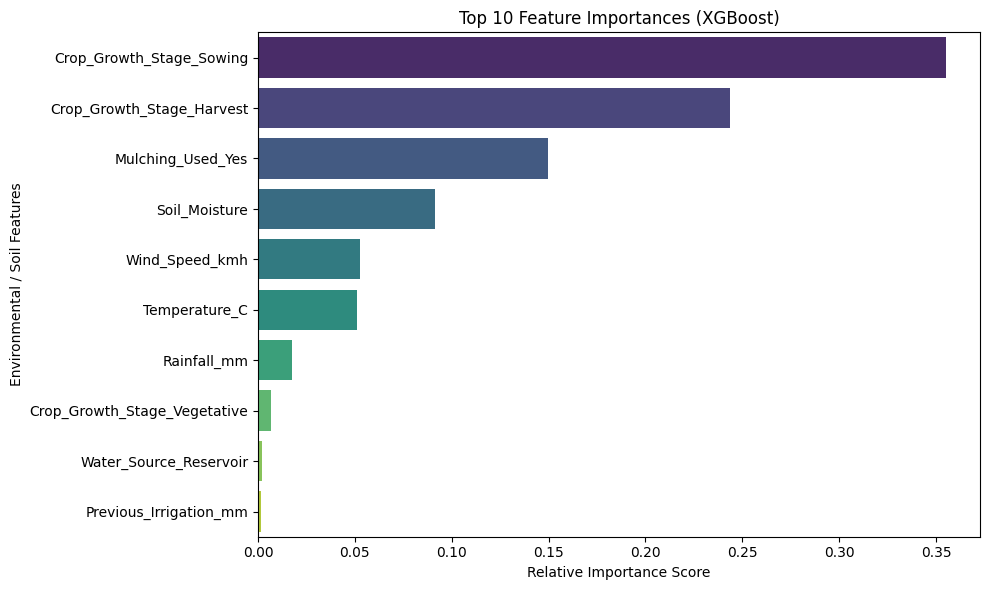

In [49]:
# Plot the top 10 most influential factors
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title(f'Top 10 Feature Importances ({top_model_name})')
plt.xlabel('Relative Importance Score')
plt.ylabel('Environmental / Soil Features')
plt.tight_layout()
plt.show()